**Задание для части 1:**
1. Рассчитайте метрику TF-IDF для любых трех песен на выбранном вами языке. (Вес задания: 30%)

2. Сравните TF-IDF с другими методами векторизации текста, такими как Count Vectorizer, Word2Vec или Doc2Vec. (Вес задания: 30%)

3. Проведите исследование, используя полученные преобразованные данные. Какие слова/фразы встречаются чаще всего, а какие реже. (Вес задания: 20%)

In [5]:
!pip install pymorphy2 nltk scikit-learn

In [6]:
import sys
print(sys.executable)

/usr/bin/python3


In [7]:
!pip install wordcloud

In [8]:
!pip install gensim

In [39]:
import pandas as pd
import numpy as np
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
import pymorphy2
import re
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec, Doc2Vec
from gensim.models.doc2vec import TaggedDocument
import time
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
import torch
from transformers import BertForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import time
import torch.nn.functional as F

In [10]:
#1 песня: Король и Шут "Кукла колдуна"
song_1 = '''
Тёмный, мрачный коридор,
Я на цыпочках, как вор,
Пробираюсь, чуть дыша,
Чтобы не спугнуть
Тех, кто спит уже давно,
Тех, кому не всё равно,
В чью я комнату тайком
Желаю заглянуть,
Чтобы увидеть...

Как бессонница в час ночной
Меняет, нелюдимая, облик твой,
Чьих невольница ты идей?
Зачем тебе охотиться на людей?

Крестик на моей груди,
На него ты погляди,
Что в тебе способен он
Резко изменить?
Много книжек я читал,
Много фокусов видал,
Свою тайну от меня
Не пытайся скрыть!
Я это видел!

Как бессонница в час ночной
Меняет, нелюдимая, облик твой,
Чьих невольница ты идей?
Зачем тебе охотиться на людей?

Очень жаль, что ты тогда
Мне поверить не смогла,
В то, что новый твой приятель
Не такой, как все!
Ты осталась с ним вдвоём,
Не зная ничего о нём.
Что для всех опасен он,
Наплевать тебе!
И ты попала!

К настоящему колдуну,
Он загубил таких, как ты, не одну!
Словно куклой и в час ночной
Теперь он может управлять тобой!
Всё происходит, как в страшном сне.
И находиться здесь опасно мне!
'''


In [11]:
#2 песня: Бонд с кнопокй "Кухни"
song_2 = '''
Простишь меня за всё или в одежде
Тихо плакать, тихо плакать
Когда устанешь, приходи, приходи, приходи
На кухни
В бережных и нежных хрущёвках
Хранилище надежд для потомков
Рассыпанная соль на клеёнке
Молоко на губах обсохло
Всё могло быть неплохо
Всё могло быть неплохо
Всё могло быть
На этих кухнях
Радостны дни твои
Радостны дни твои
Радостны дни твои
Времени вагон жить
Обувь не снимая
Спать и расходиться
По своим палатам
Простишь за всё или в одежде
Тихо плакать, безнадежно
Когда устанешь, приходи, приходи, приходи
На кухни
В бережных и нежных хрущёвках
Хранилище надежд для потомков
Рассыпанная соль на клеёнке
Молоко на губах обсохло
Всё могло быть неплохо
Всё могло быть неплохо
Всё могло быть
На этих кухнях
Радостны дни твои
Радостны дни твои
Радостны дни твои
'''

In [12]:
#3 песня: Xolidayboy "Тюлени"
song_3 = '''
Нам трезвонят телефоны
Но нам так наплевать
У нас желание одно лишь
Лежать! Лежать! Лежать!
Она хочет, со мной хочет
Этим утром, днём и ночью
Целоваться, обниматься
Плавниками прикасаться
Она хочет, со мной хочет
Этим утром, днём и ночью
Мы в кровати две недели
И валяться как тюлени
Она хочет, со мной хочет
Этим утром, днём и ночью
Целоваться, обниматься
Плавниками прикасаться
Она хочет, со мной хочет
Этим утром, днём и ночью
Мы в кровати две недели
И валяться как тюлени
Я не буду снова про дела ваши слушать
Дела — это скучно, дела — это душно
Я хотел бы просто целовать твои ушки
С перерывами на покушать
Она хочет, со мной хочет
Этим утром, днём и ночью
Целоваться, обниматься
Плавниками прикасаться
Она хочет, со мной хочет
Этим утром, днём и ночью
Мы в кровати две недели
И валяться как тюлени
Я тюлень, я тюлень
Я тюлень, и мне лень
Я тюлень, я тюлень
Я тюлень, и мне лень
Я тюлень, ты тюлень
Мы тюлени, и нам лень
Я тюлень, ты тюлень
Мы тюлени, и нам лeнь
'''

In [13]:
#собираем в один массив
songs = [song_1, song_2, song_3]

In [14]:
# Загружаем стоп-слова для русского языка
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('russian')

# Дополнительные стоп-слова
custom_stopwords = [
    'это','этот','этим','этой',
    'мной','мне','меня',
    'тебе','тебя','твой','твои',
    'нам','наш','наши',
    'всё','весь','вся',
    'свой','свои'
]

stop_words = set(stop_words + custom_stopwords)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
#Предобработка текстов песен
processed_songs = []

for song in songs:

    # 1. Приведение текста к нижнему регистру
    song = song.lower()

    # 2. Удаление переносов строк
    song = re.sub(r'\n', ' ', song)

    # 3. Удаление всех символов, кроме русских букв и пробелов
    song = re.sub(r'[^а-яё\s]', ' ', song)

    # 4. Разбиение текста на отдельные слова (токены)
    tokens = song.split()

    # 5. Удаление стоп-слов и коротких слов (меньше 3 букв)
    clean_tokens = []
    for word in tokens:
        if word not in stop_words and len(word) > 2:
            clean_tokens.append(word)

    # 6. Объединяем слова обратно в строку
    processed_songs.append(' '.join(clean_tokens))

# Вывод предобработанных текстов
print("ПРЕДОБРАБОТАННЫЕ ТЕКСТЫ:\n")
for i, text in enumerate(processed_songs):
    print(f"Песня {i+1}:\n{text[:300]}...\n")

ПРЕДОБРАБОТАННЫЕ ТЕКСТЫ:

Песня 1:
тёмный мрачный коридор цыпочках вор пробираюсь дыша спугнуть тех спит давно тех кому равно чью комнату тайком желаю заглянуть увидеть бессонница час ночной меняет нелюдимая облик чьих невольница идей охотиться людей крестик моей груди погляди способен резко изменить книжек читал фокусов видал тайну ...

Песня 2:
простишь одежде тихо плакать тихо плакать устанешь приходи приходи приходи кухни бережных нежных хрущёвках хранилище надежд потомков рассыпанная соль клеёнке молоко губах обсохло могло неплохо могло неплохо могло этих кухнях радостны дни радостны дни радостны дни времени вагон жить обувь снимая спат...

Песня 3:
трезвонят телефоны наплевать желание одно лишь лежать лежать лежать хочет хочет утром днём ночью целоваться обниматься плавниками прикасаться хочет хочет утром днём ночью кровати две недели валяться тюлени хочет хочет утром днём ночью целоваться обниматься плавниками прикасаться хочет хочет утром дн...



In [16]:
#Расчет TF-IDF

# Создаем объект TF-IDF векторизатора
vectorizer = TfidfVectorizer()

# Строим матрицу TF-IDF
tfidf_matrix = vectorizer.fit_transform(processed_songs)

# Преобразуем результат в df
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=["song_1", "song_2", "song_3"]
)

# Вывод первых столбцов матрицы
print(tfidf_df.head())

        безнадежно  бережных  бессонница      буду     вагон  валяться  \
song_1    0.000000  0.000000    0.184445  0.000000  0.000000  0.000000   
song_2    0.062017  0.124035    0.000000  0.000000  0.062017  0.000000   
song_3    0.000000  0.000000    0.000000  0.045011  0.000000  0.135034   

            ваши    вдвоём     видал     видел  ...  хранилище  хрущёвках  \
song_1  0.000000  0.092222  0.092222  0.092222  ...   0.000000   0.000000   
song_2  0.000000  0.000000  0.000000  0.000000  ...   0.124035   0.124035   
song_3  0.045011  0.000000  0.000000  0.000000  ...   0.000000   0.000000   

        целовать  целоваться  цыпочках       час     читал      чьих  \
song_1  0.000000    0.000000  0.092222  0.276667  0.092222  0.184445   
song_2  0.000000    0.000000  0.000000  0.000000  0.000000  0.000000   
song_3  0.045011    0.135034  0.000000  0.000000  0.000000  0.000000   

             чью      этих  
song_1  0.092222  0.000000  
song_2  0.000000  0.124035  
song_3  0.000000  

In [17]:
# Для каждой песни выводим 10 слов с наибольшим TF-IDF весом
for i in range(len(tfidf_df)):
    print(f"\nТоп-10 слов для song_{i+1}:")
    print(tfidf_df.iloc[i].sort_values(ascending=False).head(10))


Топ-10 слов для song_1:
ночной        0.276667
час           0.276667
охотиться     0.184445
идей          0.184445
бессонница    0.184445
людей         0.184445
меняет        0.184445
невольница    0.184445
нелюдимая     0.184445
чьих          0.184445
Name: song_1, dtype: float64

Топ-10 слов для song_2:
дни         0.372104
приходи     0.372104
радостны    0.372104
могло       0.372104
неплохо     0.248069
плакать     0.186052
тихо        0.186052
губах       0.124035
бережных    0.124035
нежных      0.124035
Name: song_2, dtype: float64

Топ-10 слов для song_3:
хочет         0.540136
тюлень        0.450113
днём          0.270068
ночью         0.270068
утром         0.270068
тюлени        0.225057
две           0.135034
дела          0.135034
валяться      0.135034
плавниками    0.135034
Name: song_3, dtype: float64


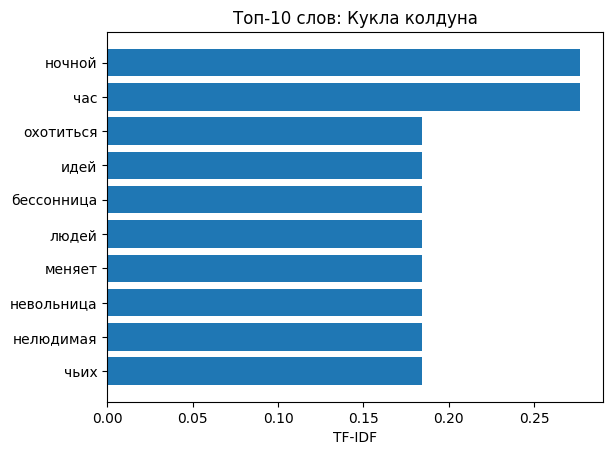

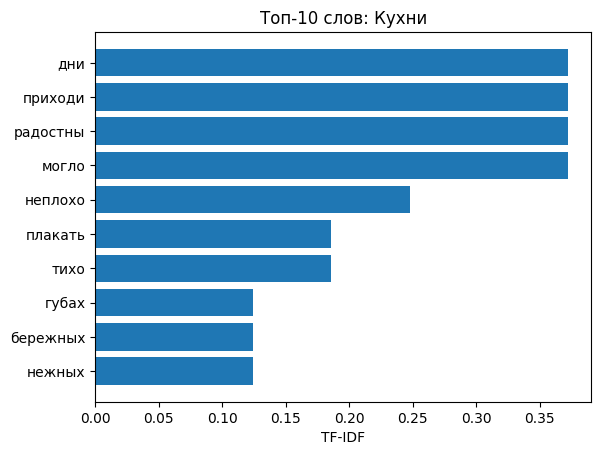

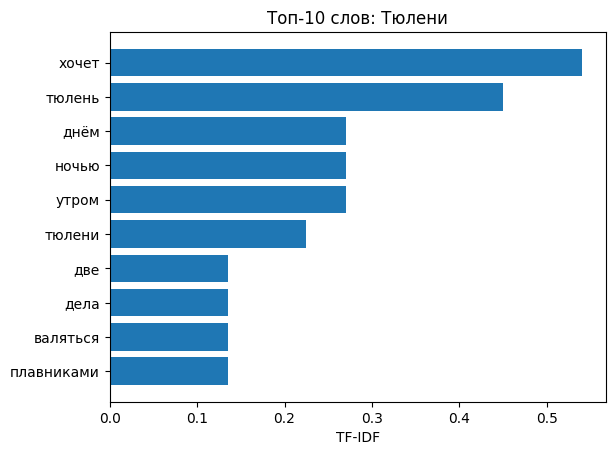

In [18]:
def plot_top_words(song_index, song_name):

    # Получаем значения TF-IDF для выбранной песни
    row = tfidf_df.iloc[song_index]

    # Сортируем слова по убыванию веса
    top_words = row.sort_values(ascending=False).head(10)

    # Создаем график
    plt.figure()
    plt.barh(top_words.index[::-1], top_words.values[::-1])
    plt.xlabel("TF-IDF")
    plt.title(f"Топ-10 слов: {song_name}")
    plt.show()

# Строим графики
plot_top_words(0, "Кукла колдуна")
plot_top_words(1, "Кухни")
plot_top_words(2, "Тюлени")

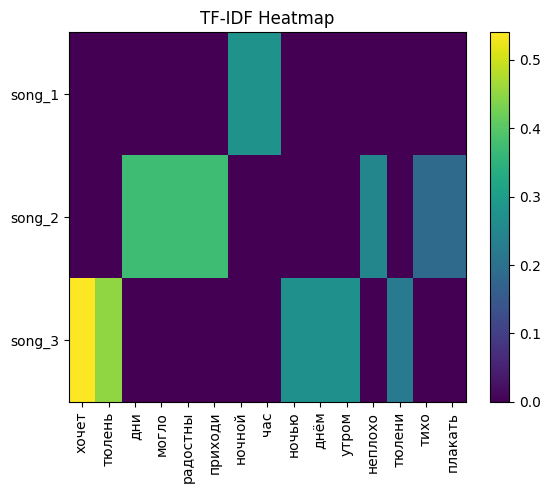

In [19]:
# Выбираем 15 слов с наибольшим суммарным весом
top_global_words = tfidf_df.sum().sort_values(ascending=False).head(15).index

# Создаем новую таблицу только с этими словами
heatmap_data = tfidf_df[top_global_words]

# Строим тепловую карту
plt.figure()
plt.imshow(heatmap_data, aspect='auto')
plt.xticks(range(len(top_global_words)), top_global_words, rotation=90)
plt.yticks(range(3), ["song_1", "song_2", "song_3"])
plt.title("TF-IDF Heatmap")
plt.colorbar()
plt.show()

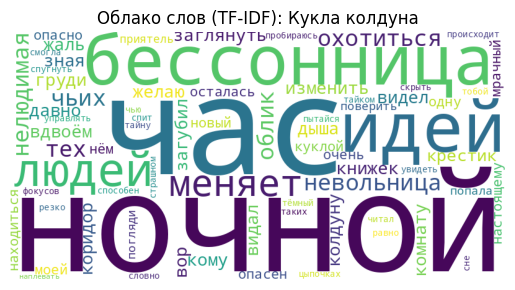

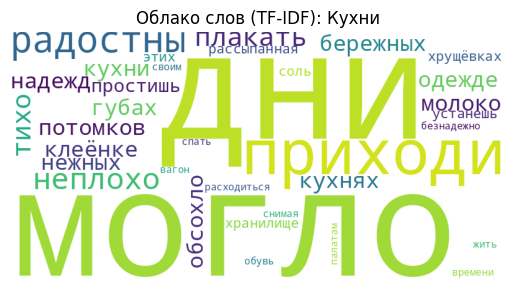

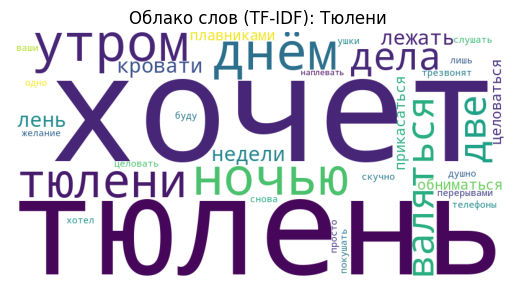

In [20]:
def plot_wordcloud(song_index, song_name):

    # Получаем TF-IDF значения для выбранной песни
    row = tfidf_df.iloc[song_index]

    # Преобразуем в словарь {слово: вес}
    word_weights = row.to_dict()

    # Создаем объект WordCloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis'
    ).generate_from_frequencies(word_weights)

    # Отображаем
    plt.figure()
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(f"Облако слов (TF-IDF): {song_name}")
    plt.show()

# Строим облака
plot_wordcloud(0, "Кукла колдуна")
plot_wordcloud(1, "Кухни")
plot_wordcloud(2, "Тюлени")

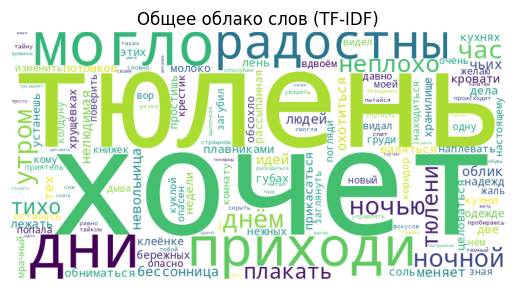

In [21]:
# Суммируем TF-IDF веса слов по всем песням
tfidf_global = tfidf_df.sum()

# Преобразуем в словарь
tfidf_dict = tfidf_global.to_dict()

# Строим облако слов
wordcloud_tfidf = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(tfidf_dict)

plt.figure()
plt.imshow(wordcloud_tfidf)
plt.axis("off")
plt.title("Общее облако слов (TF-IDF)")
plt.show()

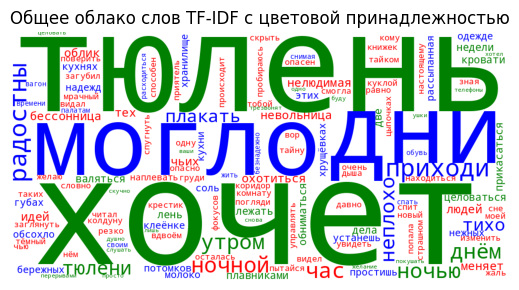

In [22]:
# Суммарные TF-IDF веса
tfidf_global = tfidf_df.sum()

# Оставим только достаточно значимые слова
tfidf_global = tfidf_global[tfidf_global > 0]

# Определяем, в какой песне слово имеет максимальный вес
word_song_map = {}

for word in tfidf_global.index:
    # Получаем значения TF-IDF по всем песням
    values = tfidf_df[word]

    # Находим индекс песни с максимальным значением
    max_song_index = np.argmax(values)
    word_song_map[word] = max_song_index

# Функция окраски слов
def color_func(word, *args, **kwargs):
    song_index = word_song_map[word]

    if song_index == 0:
        return "red"      # song_1
    elif song_index == 1:
        return "blue"     # song_2
    else:
        return "green"    # song_3

# Строим облако
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate_from_frequencies(tfidf_global.to_dict())

plt.figure()
plt.imshow(wordcloud.recolor(color_func=color_func))
plt.axis("off")
plt.title("Общее облако слов TF-IDF с цветовой принадлежностью")
plt.show()

In [23]:
#Слова из первой песни наименее значимые в облаке. Дополнительно проанализируем слова
# Топ слов первой песни
top_words_song1 = tfidf_df.iloc[0].sort_values(ascending=False).head(10).index.tolist()

# Песни 2 и 3
songs_other = [processed_songs[1], processed_songs[2]]

for word in top_words_song1:
    appears_in_others = any(word in song.split() for song in songs_other)
    print(f"Слово '{word}' встречается в других песнях? {'Да' if appears_in_others else 'Нет'}")

Слово 'ночной' встречается в других песнях? Нет
Слово 'час' встречается в других песнях? Нет
Слово 'охотиться' встречается в других песнях? Нет
Слово 'идей' встречается в других песнях? Нет
Слово 'бессонница' встречается в других песнях? Нет
Слово 'людей' встречается в других песнях? Нет
Слово 'меняет' встречается в других песнях? Нет
Слово 'невольница' встречается в других песнях? Нет
Слово 'нелюдимая' встречается в других песнях? Нет
Слово 'чьих' встречается в других песнях? Нет


In [24]:
all_words_list = []
for i, song_name in enumerate(["song_1", "song_2", "song_3"]):
    row = tfidf_df.iloc[i]
    for word, value in row.items():
        if value > 0:
            all_words_list.append({
                "слово": word,
                "песня": song_name,
                "tf-idf": round(value, 3)
            })

all_words_df = pd.DataFrame(all_words_list)
all_words_df = all_words_df.sort_values(by="tf-idf", ascending=False).reset_index(drop=True)
print(all_words_df.head(20))

         слово   песня  tf-idf
0        хочет  song_3   0.540
1       тюлень  song_3   0.450
2        могло  song_2   0.372
3          дни  song_2   0.372
4     радостны  song_2   0.372
5      приходи  song_2   0.372
6       ночной  song_1   0.277
7          час  song_1   0.277
8        ночью  song_3   0.270
9        утром  song_3   0.270
10        днём  song_3   0.270
11     неплохо  song_2   0.248
12      тюлени  song_3   0.225
13        тихо  song_2   0.186
14     плакать  song_2   0.186
15         тех  song_1   0.184
16        чьих  song_1   0.184
17  невольница  song_1   0.184
18   охотиться  song_1   0.184
19       облик  song_1   0.184


**ВЫВОД TF-IDF:**
В таблице представлены все слова, участвующие в построении общего облака, с указанием песни и значений TF-IDF. Из неё видно, что слова третьей песни («хочет», «тюлень») имеют наибольший вес, слова второй песни — средний, а слова первой песни («ночной», «час», «охотиться» и др.) — относительно маленький. Это объясняется особенностями метрики TF-IDF: она учитывает не только уникальность слова в корпусе (IDF), но и его частоту внутри самой песни (TF). Поскольку слова первой песни встречаются реже, их TF-IDF значение ниже, даже несмотря на то, что они уникальны для этой песни. В то же время часто повторяющиеся слова третьей песни получают высокий вес. Такое распределение весов объясняет различие размеров слов в облаке: крупными визуально становятся слова, которые одновременно уникальны для песни и часто повторяются в ней, а редкие слова, пусть и уникальные, отображаются меньшим размером.


In [25]:
#Сравним методы векторизации
documents = processed_songs
results = []

#CountVectorizer
start = time.time()
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(documents)
end = time.time()
results.append({
    "Метод": "CountVectorizer",
    "Время (сек)": round(end - start, 4),
})

#TF-IDF
start = time.time()
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
end = time.time()
results.append({
    "Метод": "TF-IDF",
    "Время (сек)": round(end - start, 4),
})

#Word2Vec
tokenized_docs = [doc.split() for doc in documents]
start = time.time()
w2v_model = Word2Vec(sentences=tokenized_docs, vector_size=50, window=5, min_count=1, workers=1)
end = time.time()
results.append({
    "Метод": "Word2Vec",
    "Время (сек)": round(end - start, 4),
})

#Doc2Vec
tagged_docs = [TaggedDocument(words=doc.split(), tags=[str(i)]) for i, doc in enumerate(documents)]
start = time.time()
d2v_model = Doc2Vec(documents=tagged_docs, vector_size=50, window=5, min_count=1, workers=1)
end = time.time()
results.append({
    "Метод": "Doc2Vec",
    "Время (сек)": round(end - start, 4),
})

comparison_df = pd.DataFrame(results)
comparison_df

,Метод,Время (сек)
0,CountVectorizer,0.0021
1,TF-IDF,0.0020
2,Word2Vec,0.0100
3,Doc2Vec,0.0156


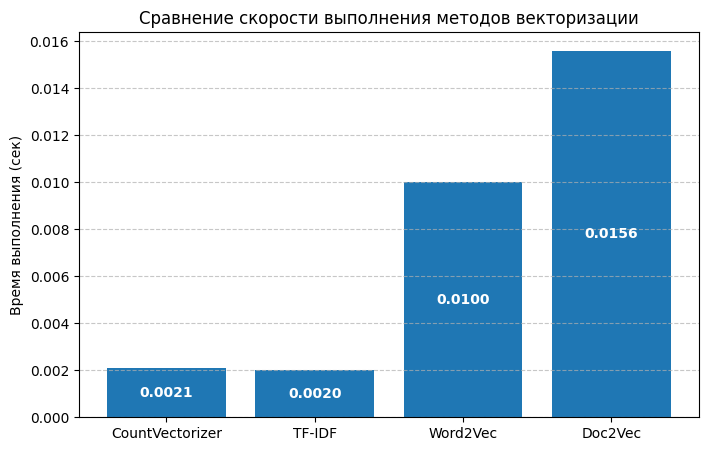

In [26]:
plt.figure(figsize=(8,5))
bars = plt.bar(comparison_df["Метод"], comparison_df["Время (сек)"])
plt.ylabel("Время выполнения (сек)")
plt.title("Сравнение скорости выполнения методов векторизации")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Подписи внутри столбцов
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height/2, f"{height:.4f}", ha='center', va='center', color='white', fontweight='bold')

plt.show()

График демонстрирует вычислительную эффективность методов векторизации текста. TF-IDF и CountVectorizer значительно быстрее Word2Vec и Doc2Vec, что делает их предпочтительными для анализа текстов когда важна скорость обработки и интерпретируемость результатов.


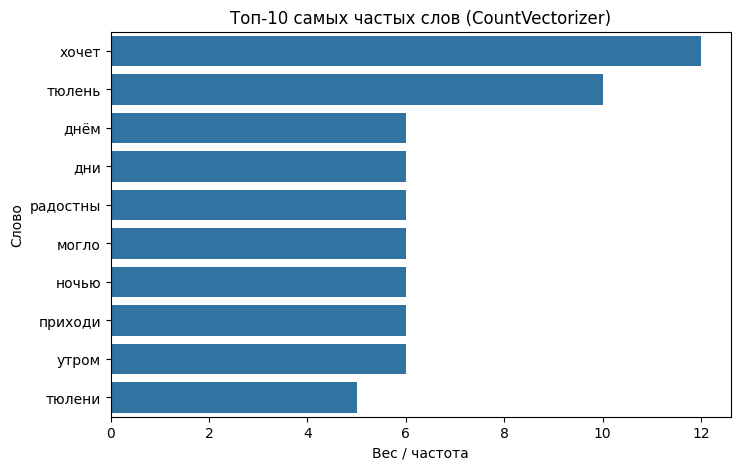

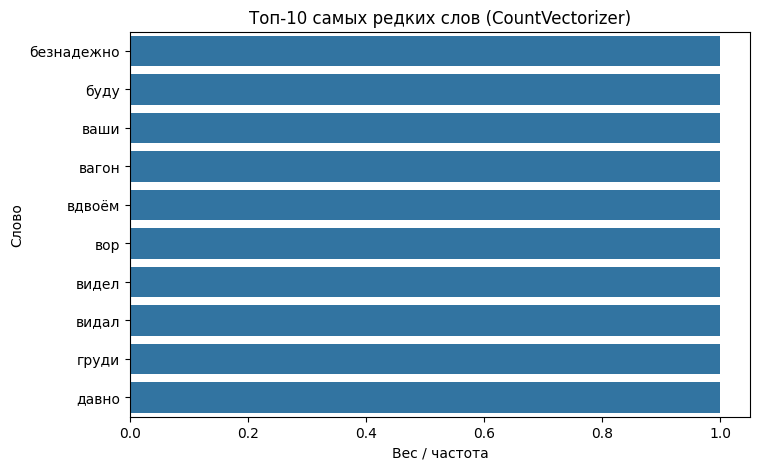

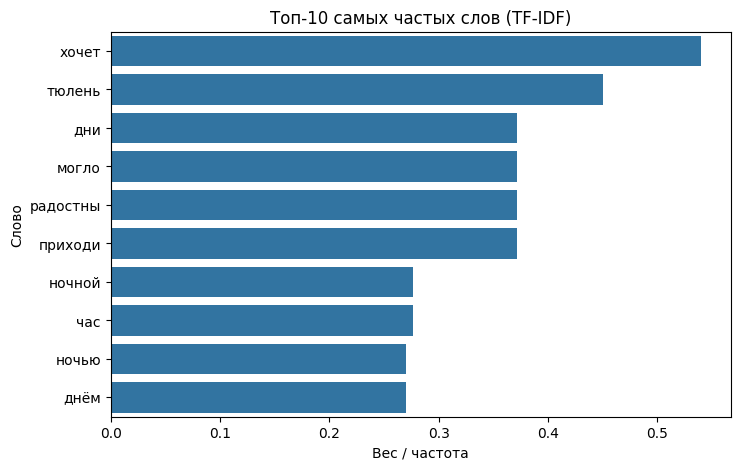

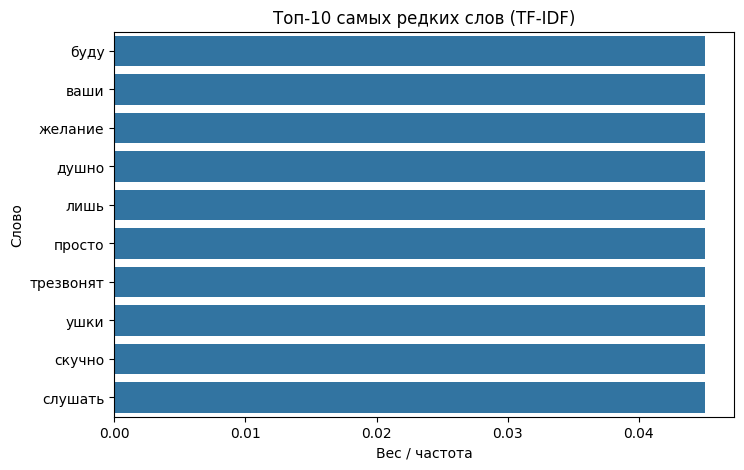

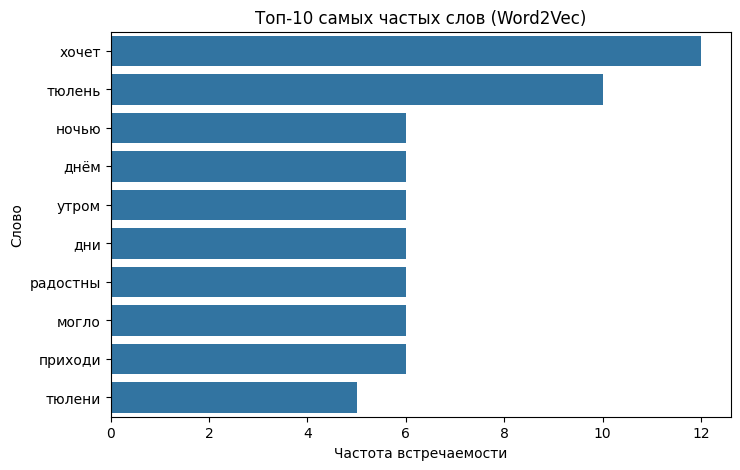

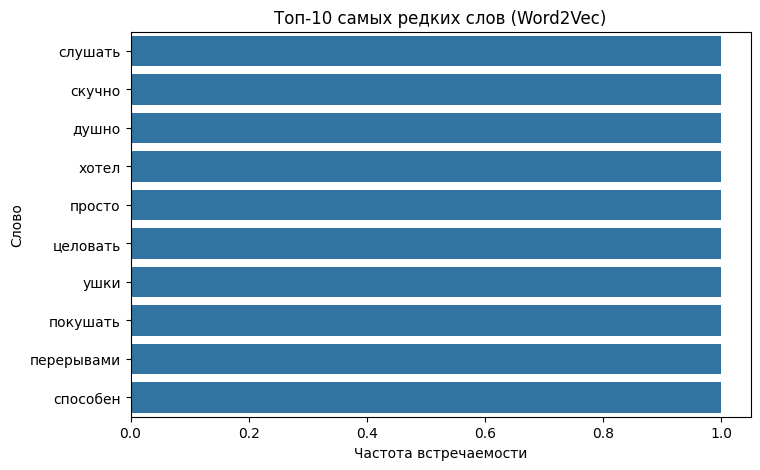

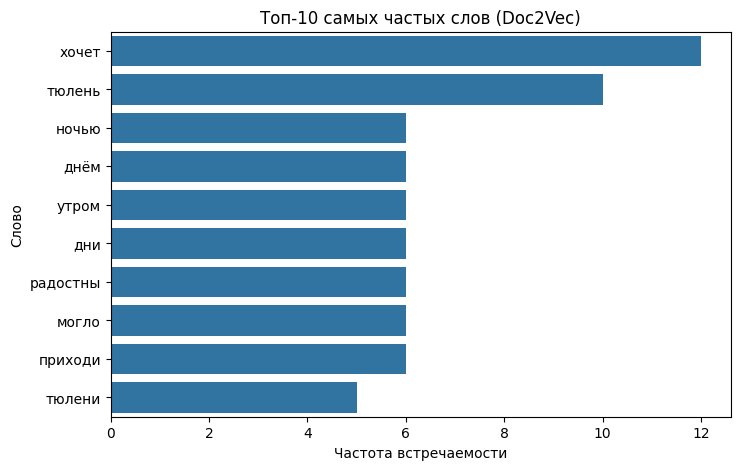

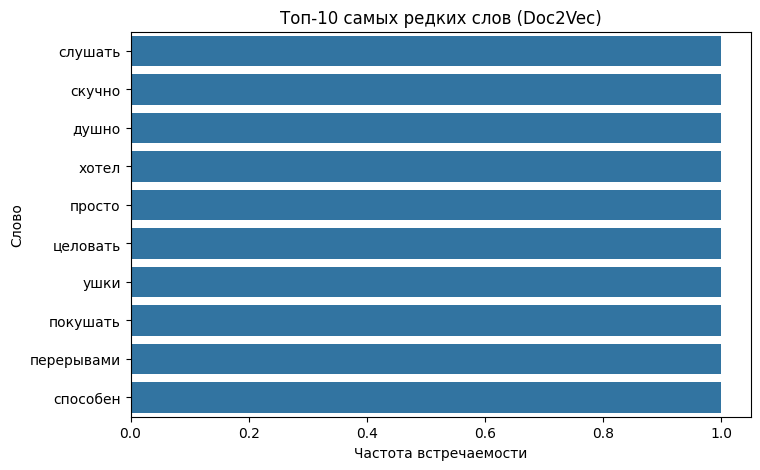

In [27]:
#Сравним частые и редкие слова в каждом методе

def plot_top_bottom_words(matrix, feature_names, method_name):
    """
    Построение графиков топ-10 частых и редких слов для CountVectorizer/TF-IDF
    """
    word_counts = np.asarray(matrix.sum(axis=0)).flatten()
    df = pd.DataFrame({"word": feature_names, "count": word_counts})

    df_top = df.sort_values("count", ascending=False).head(10)
    df_bottom = df[df["count"] > 0].sort_values("count", ascending=True).head(10)

    plt.figure(figsize=(8,5))
    sns.barplot(y="word", x="count", data=df_top)
    plt.title(f"Топ-10 самых частых слов ({method_name})")
    plt.xlabel("Вес / частота")
    plt.ylabel("Слово")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.barplot(y="word", x="count", data=df_bottom)
    plt.title(f"Топ-10 самых редких слов ({method_name})")
    plt.xlabel("Вес / частота")
    plt.ylabel("Слово")
    plt.show()


#CountVectorizer
plot_top_bottom_words(count_matrix, count_vectorizer.get_feature_names_out(), "CountVectorizer")

#TF-IDF
plot_top_bottom_words(tfidf_matrix, tfidf_vectorizer.get_feature_names_out(), "TF-IDF")

#Word2Vec
word_counts_w2v = [(word, w2v_model.wv.get_vecattr(word, "count")) for word in w2v_model.wv.index_to_key]
df_w2v = pd.DataFrame(word_counts_w2v, columns=["word", "count"])

df_w2v_top = df_w2v.sort_values("count", ascending=False).head(10)
df_w2v_bottom = df_w2v.sort_values("count", ascending=True).head(10)

plt.figure(figsize=(8,5))
sns.barplot(y="word", x="count", data=df_w2v_top)
plt.title("Топ-10 самых частых слов (Word2Vec)")
plt.xlabel("Частота встречаемости")
plt.ylabel("Слово")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(y="word", x="count", data=df_w2v_bottom)
plt.title("Топ-10 самых редких слов (Word2Vec)")
plt.xlabel("Частота встречаемости")
plt.ylabel("Слово")
plt.show()


#Doc2Vec
#Doc2Vec не даёт веса для слов напрямую, поэтому используем усреднение встречаемости слов
word_counts_d2v = [(word, d2v_model.wv.get_vecattr(word, "count")) for word in d2v_model.wv.index_to_key]
df_d2v = pd.DataFrame(word_counts_d2v, columns=["word", "count"])

df_d2v_top = df_d2v.sort_values("count", ascending=False).head(10)
df_d2v_bottom = df_d2v.sort_values("count", ascending=True).head(10)

plt.figure(figsize=(8,5))
sns.barplot(y="word", x="count", data=df_d2v_top)
plt.title("Топ-10 самых частых слов (Doc2Vec)")
plt.xlabel("Частота встречаемости")
plt.ylabel("Слово")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(y="word", x="count", data=df_d2v_bottom)
plt.title("Топ-10 самых редких слов (Doc2Vec)")
plt.xlabel("Частота встречаемости")
plt.ylabel("Слово")
plt.show()

**CountVectorizer** - выделяет самые часто встречающиеся слова, но не учитывает их уникальность.

**TF-IDF** - поднимает уникальные или значимые слова для каждой песни; редкие слова становятся заметными, а очень частые по всем песням снижаются.

**Word2Vec** - показывает частые слова по количеству встречаемости при обучении. Редкие слова встречаются мало, но семантически близкие могут группироваться вместе.

**Doc2Vec** - аналогично Word2Vec, но учитывает контекст всей песни. Редкие слова слабо представлены, а часто встречающиеся слова доминируют.


TF-IDF и CountVectorizer дают явное представление важности слов, легко интерпретируются.

Word2Vec и Doc2Vec - лучше для контекста, но частота слов не всегда отражает их значение, особенно на маленьком корпусе.

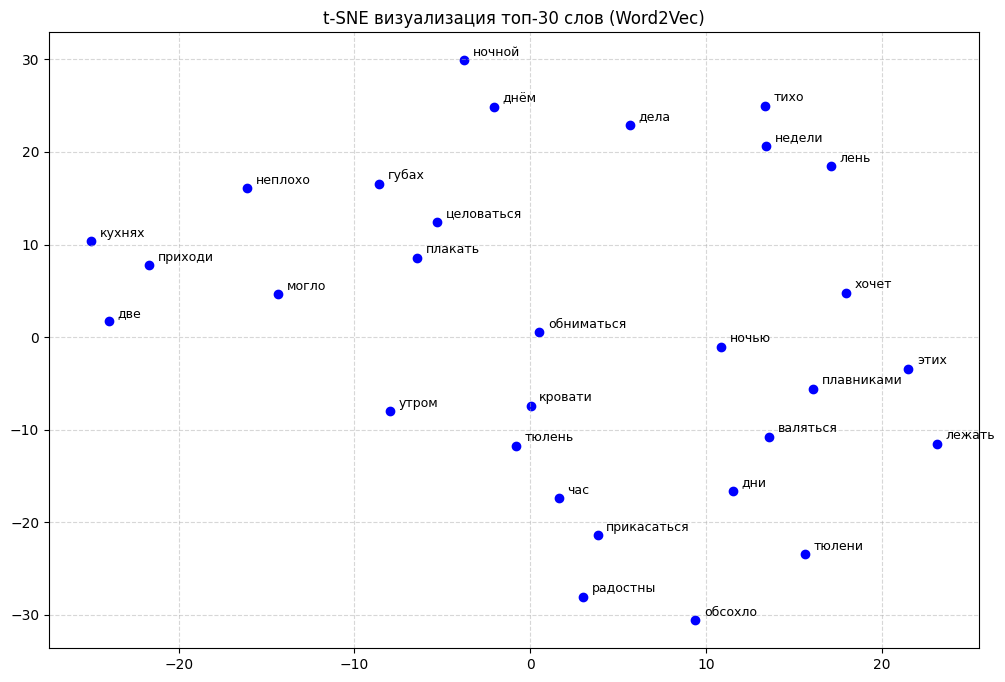

In [28]:
#Построим t-sne визуализацию по Word2Vec методу. Визуализация показывает насколько хожи слова по смыслу
# Берём топ-30 самых часто встречающихся слов
top_n = 30
words_sorted_by_count = sorted(w2v_model.wv.index_to_key, key=lambda w: w2v_model.wv.get_vecattr(w, "count"), reverse=True)
top_words_w2v = words_sorted_by_count[:top_n]

# Получаем векторы этих слов
word_vectors = np.array([w2v_model.wv[word] for word in top_words_w2v])

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
tsne_result = tsne.fit_transform(word_vectors)
plt.figure(figsize=(12,8))
plt.scatter(tsne_result[:,0], tsne_result[:,1], color='blue')

for i, word in enumerate(top_words_w2v):
    plt.text(tsne_result[i,0]+0.5, tsne_result[i,1]+0.5, word, fontsize=9)

plt.title(f"t-SNE визуализация топ-{top_n} слов (Word2Vec)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Визуализация t-SNE на малом корпусе текстов (трёх песен) в целом даёт нестабильные результаты: из-за ограниченного объёма данных и небольшой частоты слов многие векторы не отражают реальную семантическую схожесть. Тем не менее, даже на таком маленьком корпусе можно заметить смысловые связи между некоторыми словами - «днём» и «ночной» или «губах» и «целоваться» расположены рядом, что соответствует их контексту в текстах песен

**Итог 1 часть:**
Были рассчитаны TF-IDF значения для трёх песен и проведено сравнение с CountVectorizer, Word2Vec и Doc2Vec. TF-IDF выделяет уникальные и значимые слова, CountVectorizer — самые частые, а Word2Vec и Doc2Vec показывают семантические связи. Анализ топ-слов и редких слов подтвердил, какие слова доминируют в текстах, а какие встречаются реже.

**Задание для части 2:**

4. Используйте предварительно обученную модель BERT для классификации тональности отзывов о фильмах.

In [29]:
#Загружаем датасет

df = pd.read_csv("/kaggle/input/datasets/ekaterinazin/imdb-dataset/IMDB Dataset.csv")
print(df.head())


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [30]:
# Добавляем метки: 'positive' -> 1, 'negative' -> 0
df['label'] = df['sentiment'].map({'positive':1, 'negative':0})

In [31]:
# Разделение на трейн и тест
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['review'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)

In [32]:
# Токенизация BERT
model_name = "bert-base-uncased"  # английская BERT
tokenizer = BertTokenizer.from_pretrained(model_name)

# Токенизация: добавляем паддинг и обрезку до max_length
max_length = 256
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [33]:
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = IMDBDataset(train_encodings, train_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

In [34]:
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Далее реализуем цикл обучения модели с использованием mixed precision для ускорения работы на GPU.

Модель переносится на устройство (GPU), данные загружаются батчами через DataLoader, а оптимизация выполняется с помощью AdamW.
Блок autocast() позволяет выполнять часть вычислений в пониженной точности, что ускоряет обучение и уменьшает потребление памяти. GradScaler масштабирует функцию потерь перед обратным распространением ошибки, обеспечивая стабильность градиентов.

In [35]:
from torch.cuda.amp import autocast, GradScaler

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
optimizer = AdamW(model.parameters(), lr=5e-5)

# Инициализация GradScaler для mixed precision
scaler = GradScaler()

model.train()
for epoch in range(2):
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Используем autocast для mixed precision
        with autocast():
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        # Масштабируем градиенты
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())

/tmp/ipykernel_55/2115595401.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/2500 [00:00<?, ?it/s]/tmp/ipykernel_55/2115595401.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1: 100%|██████████| 2500/2500 [09:56<00:00,  4.19it/s, loss=0.071]  


In [36]:
test_loader = DataLoader(test_dataset, batch_size=16)

model.eval()
preds = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)

        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

acc = accuracy_score(true_labels, preds)
prec = precision_score(true_labels, preds)
rec = recall_score(true_labels, preds)
f1 = f1_score(true_labels, preds)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9043
Precision: 0.8590
Recall: 0.9692
F1-score: 0.9108


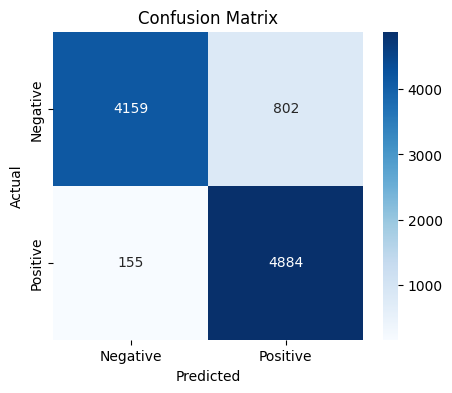

In [37]:
#Посмотрим матрицу ошибок
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        # Переносим данные на устройство
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Прямой проход
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        # ОБЯЗАТЕЛЬНО переносим обратно на CPU
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Строим confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Матрица ошибок показывает, что модель корректно классифицирует большинство отзывов: 4159 отрицательных и 4884 положительных были предсказаны верно. Ошибки распределены несимметрично — модель немного чаще относит отрицательные отзывы к положительным (802 случая), чем наоборот (155 случаев). В целом результаты подтверждают высокое качество модели и её способность надёжно различать тональность отзывов.

In [40]:
#Рассмотрим на примерах
model.eval()

examples = [
    "This movie was absolutely fantastic. I really loved it!",
    "Terrible movie. Waste of time.",
    "It was okay, not great but not bad either.",
    "One of the best films I have ever seen.",
    "The plot was boring and predictable."
]

# Токенизация всех примеров сразу
encodings = tokenizer(
    examples,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

encodings = {key: value.to(device) for key, value in encodings.items()}

start_time = time.time()

with torch.no_grad():
    outputs = model(**encodings)
    logits = outputs.logits
    probs = F.softmax(logits, dim=1)
    predictions = torch.argmax(probs, dim=1)

end_time = time.time()

total_time = end_time - start_time
avg_time = total_time / len(examples)

for i, text in enumerate(examples):
    pred_label = "Positive" if predictions[i].item() == 1 else "Negative"
    confidence = probs[i][predictions[i]].item()
    
    print(f"\nТекст: {text}")
    print(f"Предсказание: {pred_label}")
    print(f"Уверенность: {confidence:.4f}")

print("\nОбщее время обработки батча:", f"{total_time:.6f} секунд")
print("Среднее время на один отзыв:", f"{avg_time:.6f} секунд")


Текст: This movie was absolutely fantastic. I really loved it!
Предсказание: Positive
Уверенность: 0.9950

Текст: Terrible movie. Waste of time.
Предсказание: Negative
Уверенность: 0.9979

Текст: It was okay, not great but not bad either.
Предсказание: Positive
Уверенность: 0.5019

Текст: One of the best films I have ever seen.
Предсказание: Positive
Уверенность: 0.9948

Текст: The plot was boring and predictable.
Предсказание: Negative
Уверенность: 0.9985

Общее время обработки батча: 0.105860 секунд
Среднее время на один отзыв: 0.021172 секунд


**Итог 2 часть:**
Предобученная модель BERT была дообучена для задачи бинарной классификации тональности отзывов. На тестовой выборке модель показала Accuracy = 0.9043 и F1-score = 0.9108, что говорит о высоком качестве классификации и хорошем балансе между precision (0.8590) и recall (0.9692).

Матрица ошибок показала, что модель корректно распознаёт большинство положительных и отрицательных отзывов, при этом немного чаще относит нейтральные или спорные отзывы к положительному классу.

Среднее время обработки одного отзыва составляет примерно 0.02 секунды, что делает модель пригодной для практического применения. В целом, результаты подтверждают эффективность предобученной модели BERT для задачи анализа тональности текста.